In [304]:
import numpy as np
'Sparse matrix solvers'
from scipy.sparse import coo_matrix, csc_matrix
from scipy.sparse.linalg import spsolve
'Rectangular mesh creation'
from meshing import rectangularmesh
'Boundary condition utility functons'
from Utilities import CCCC, SSSS, V_Beam, H_Beam, UniformLoad
'Plotting functions'
from plots import Plot_PlateNodes, Plot_PlateCenter

This is a Finite Element implementation to analyze plate bending of Kirchoff plates, based on the book "The Implementation of the Finite Element Method" by `Viktor Hristovski`. The goal of this notebook is to give an overview of the theoretical background of the plate bending problem and give a basic Python implementation. The structure of this notebook is divided into steps, each one containing a theoretical explanation followed by its respective implementation. This is particularly helpfull to develop a deeper understanding of the algorithm, keeping track at which step is each variable created and of course clarify important concepts regarding the theoretical background. The units used in this implementation are specified after the creation of each variable, therefore to change the unit system the reader must look for the commented text after each variable and specify its value in the desired unit system.

**Section 1: Defining the Plate Geometry**

The rectangular plate has dimensions $L_x$, $L_y$, and thickness $t$, and it is subdivided into $E_x$ and $E_y$ equal sections along axes $x$ and $y$ respectively. This yields a total of $E_xE_y$ **rectangular elements** and a total of $(E_x+1)(E_y+1)$ **mesh nodes**.

In [305]:
'Plate Geometric Properties (cm)'
LX = 1500 #Plate length in x direction (cm)
LY = 1500 #Plate length in y direction (cm)
EX = 3*7 #Number of subdivisions in x direction
EY = 3*7 #Number of subdivisions in y direction
t = 3 #Plate thickness (cm)
Elements = EX*EY

To create the mesh, we use the "rectangularmesh" function which can be consulted in the script "meshing.py". It creates a uniform rectangular mesh with the desired dimensions $L_x$ and $L_y$, in which the $0$-th rectangular element is in the lower-left position, the first element is the element adjacent in the $y$ direction, the $E_y$-th element is the element adjacent in the $x$ direction, and the $(ExEy-1)$-th (the last element in the list) is in the upper right position. Throughout the implementation we fix a particular ordering of the **mesh nodes**. The $0$-th mesh node is in the lower left position and the node numbering increases in the $y$ direction with the $(E_y+1)$-th node appearing at the right of the $0$th node.

In [306]:
'Create a rectangular mesh of sides LX, LY with EX and EY subdivisions with Lower Left mesh node at coordinate (0,0)'
RectOutput = rectangularmesh(LX, LY, EX, EY, 0, 0)
NodeCoord = RectOutput[0]
ElementNodes = RectOutput[1]
'Print the coordinates of the first element'
idx_first = ElementNodes[0].astype(int)
print('Node numbers for element 0:')
print(idx_first)
Q_first = NodeCoord[idx_first, :]
print('Node Coordinates:')
print(Q_first)
'Print the coordinates of the last element (EX*EY - 1:)'
idx_last = ElementNodes[EX*EY - 1].astype(int)
print('Node numbers for element EX*EY-1:')
print(idx_last)
Q_last = NodeCoord[idx_last, :]
print('Node Coordinates:')
print(Q_last)

Node numbers for element 0:
[ 0  1 22 23]
Node Coordinates:
[[ 0.          0.        ]
 [ 0.         71.42857143]
 [71.42857143  0.        ]
 [71.42857143 71.42857143]]
Node numbers for element EX*EY-1:
[460 461 482 483]
Node Coordinates:
[[1428.57142857 1428.57142857]
 [1428.57142857 1500.        ]
 [1500.         1428.57142857]
 [1500.         1500.        ]]


**Step 2: Plate Bending Problem Formulation**

The two-dimensional analog of the Euler-Bernouli beam theory is called the Kirchoff plate theory. The equivalence consists on the assumption that cross-sections normal to the middle plane remain plane and normal after the bending deformation following Bernouli's hypothesis. In Kirchoff plate theory deformations due to shear forces are neglected. This is justified as long as both conditions $t/L_x\leq .1$ and $t/L_y \leq .1$ hold (also for the plate elements), otherwise the Reissner-Mindlin's model of a thick plate should be used, which is the 2-dimensional analog of a Timoshenko Beam. It is also assumed that the load always acts perpendicular to the mid-surface of the plate.

In [307]:
print('t/(LX/EX):=' + str(t/(LX/EX)))
if t/(LX/EX) < .1:
    print('t/(LX/EX) <= .1 => OK, Kirchoff theory applies')
else:
    print('t/(LX/EX) > .1 => NO OK, Reissner-Midlin theory should be used')
print('t/(LY/EY):=' + str(t/(LY/EY)))
if t/(LY/EY) < .1:
    print('t/(LY/EY) <= .1 => OK, Kirchoff theory applies')
else:
    print('t/(LY/EY) > .1 => NO OK, Reissner-Midlin theory should be used')

t/(LX/EX):=0.041999999999999996
t/(LX/EX) <= .1 => OK, Kirchoff theory applies
t/(LY/EY):=0.041999999999999996
t/(LY/EY) <= .1 => OK, Kirchoff theory applies


Consider a cross-section $A-A'$ with thickness $t$, where the following forces act upon a unit width element in the $y$ direction: Axial force $N_x$ in the $x$-direction, shear force $Q_x$ in the $x$-direction and bending moment $M_x$ around the $y$ axis. The plate strip is subjected to bending due to a load $q_z(x,y)$, while the resulting **deformations** (in the middle plane $z=0$) in **axial direction** $u(x,y)=u_0(x)$, in **vertical direction** $w(x,y)=w_0(x)$ as well as **rotation of the cross section** $\theta_x(x,y)$ are shown in the following figure.

Figure with the structural problem.

Unlike beam theory, in plate theory three moments act on the plate's surface, namely $M_x$ and $M_y$ in the direction of global axes $x$ and $y$ respectively and torsion $M_{xy}$. Shear forces $Q_x$ and $Q_y$ act on each of the two global directions $x$ and $y$ of the plate. To derive the equilibrium differential equation of a thin plate by considering both directions $x$ and $y$ we consider the following equilibrium relationships:
$$
\begin{bmatrix}
\frac{\delta}{\delta x} & \frac{\delta}{\delta y}
\end{bmatrix}
\begin{bmatrix}
Q_x \\
Q_y
\end{bmatrix}
+ q_z(x,y) = 0, (2.1)
$$
$$
\begin{bmatrix}
\frac{\delta}{\delta x} & 0 &\frac{\delta}{\delta y} \\
0 & \frac{\delta}{\delta y} &\frac{\delta}{\delta x} \\
\end{bmatrix}
\begin{bmatrix}
M_x \\
M_y \\
M_{xy}
\end{bmatrix} +
\begin{bmatrix}
Q_x \\
Q_y
\end{bmatrix} = 
\mathbf{D}_M \sigma + \mathbf{Q} = 0, (2.2).
$$
The shear force vector $\mathbf{Q}$ in Equation (2.2) can be expressed as a function of the moments and the resulting expression substituted in Equation (2.1) to obtain the following scalar differential equation:
$$
-q_z(x,y) =
\begin{bmatrix}
\frac{\delta}{\delta x} & \frac{\delta}{\delta y}
\end{bmatrix}
\begin{bmatrix}
Q_x \\
Q_y
\end{bmatrix} =
\begin{bmatrix}
\frac{\delta}{\delta x} & \frac{\delta}{\delta y}
\end{bmatrix}
\begin{bmatrix}
\frac{\delta}{\delta x} & 0 &\frac{\delta}{\delta y} \\
0 & \frac{\delta}{\delta y} &\frac{\delta}{\delta x} \\
\end{bmatrix}
\begin{bmatrix}
M_x \\
M_y \\
M_{xy}
\end{bmatrix} =
\frac{\delta^2 M_x}{\delta x^2} + \frac{\delta^2 M_y}{\delta y^2} + 2\frac{\delta^2 M_{xy}}{\delta x \delta y},
$$
that is, the **equilibrium equation** governing the bending of thin plates expressed as a function of the moments $M_x, M_y, M_{xy}$. It can be expressed in matrix form as follows:
$$
q_z(x,y) = \frac{\delta^2 M_x}{\delta x^2} + \frac{\delta^2 M_y}{\delta y^2} + 2\frac{\delta^2 M_{xy}}{\delta x \delta y} = 
\begin{bmatrix}
\frac{\delta^2}{\delta x^2} & \frac{\delta^2}{\delta y^2} & 2\frac{\delta^2}{\delta x \delta y}
\end{bmatrix}
\begin{bmatrix}
M_x \\
M_y \\
M_{xy}
\end{bmatrix} = \mathbf{D}_{eq} \sigma, (2.3).
$$
Next, consider the **constitutive relationships** for bending of thin plates, that is $\mathbf{M} = -\mathbf{D} \kappa$, which in developped form is:
$$
\begin{bmatrix}
M_x \\
M_y \\
M_{xy}
\end{bmatrix} = 
-\frac{E t^3}{12(1 - \nu^2)} 
\begin{bmatrix}
1 & \nu & 0 \\
\nu & 1 & 0 \\
0 & 0 & \frac{(1 - \nu)}{2} \\
\end{bmatrix}
\begin{bmatrix}
\kappa_x \\
\kappa_y \\
\kappa_{xy}
\end{bmatrix}=
-\frac{E t^3}{12(1 - \nu^2)}
\begin{bmatrix}
1 & \nu & 0 \\
\nu & 1 & 0 \\
0 & 0 & \frac{(1 - \nu)}{2} \\
\end{bmatrix}
\begin{bmatrix}
\frac{\delta^2}{\delta x}\\
\frac{\delta^2}{\delta y}\\
2\frac{\delta^2}{\delta x \delta y}\\
\end{bmatrix} w \sim -\mathbf{D} \mathbf{D}_{\kappa} \mathbf{u}, (2.4)
$$
where $E$ is the **elasticity modulus**, $\nu$ the **Poisson's ratio** , and the analog of strains $\epsilon$ in plane stress for thin plates are the curvatures $\kappa$, meaning the analog kinematic equations are:
$$
\kappa =
\begin{bmatrix}
\kappa_x \\
\kappa_y \\
\kappa_{xy}
\end{bmatrix}=
\begin{bmatrix}
\frac{\delta^2}{\delta x}\\
\frac{\delta^2}{\delta y}\\
2\frac{\delta^2}{\delta x \delta y}\\
\end{bmatrix} w \sim \mathbf{D}_{\kappa} \mathbf{u},
$$
where the analog vector of unknowns $u$ is the desplacement in the vertical direction $w(x,y)$. Substituting (2.4) in (2.3) the following final differential equation for thin plate bending in matrix form is obtained:
$$
q_z(x,y) = 
\begin{bmatrix}
\frac{\delta^2}{\delta x^2} & \frac{\delta^2}{\delta y^2} & 2\frac{\delta^2}{\delta x \delta y}
\end{bmatrix}
\frac{E t^3}{12(1 - \nu^2)}
\begin{bmatrix}
1 & \nu & 0 \\
\nu & 1 & 0 \\
0 & 0 & \frac{(1 - \nu)}{2} \\
\end{bmatrix}
\begin{bmatrix}
\frac{\delta^2}{\delta x}\\
\frac{\delta^2}{\delta y}\\
2\frac{\delta^2}{\delta x \delta y}\\
\end{bmatrix} w \sim 
\mathbf{D}_{eq} \mathbf{D} \mathbf{D}_K \mathbf{u} = \mathbf{D}^T_K \mathbf{D} \mathbf{D}_K \mathbf{u},(2.5)
$$
or taking $D = \frac{E t^3}{12(1 - \nu^2)}$ the well known **biharmonic equation** from classic plate bending theory,
$$
q_z(x,y) = \frac{\delta ^2}{\delta x^2} \big[ D(\frac{\delta^2 w}{\delta x^2} + \nu \frac{\delta^2 w}{\delta y^2}) \big]
+ 2\frac{\delta ^2}{\delta x \delta y} \big[ D(1 - \nu) \frac{\delta^2 w}{\delta x \delta y} \big]
+ \frac{\delta ^2}{\delta y^2} \big[ D(\frac{\delta^2 w}{\delta y^2} + \nu \frac{\delta^2 w}{\delta x^2}) \big].
$$
In classic plate bending literature this equation is often expressed as the biharmonic Lagrange equation
$$
q_z(x,y) = D(\frac{\delta^4 w}{\delta x^4}+\frac{\delta^4 w}{\delta y^4}+ \frac{\delta^4 w}{\delta x^2 \delta y^2}).
$$

Finally, the material properties are introduced in a material matrix, where the Elasticity modulus and the Poisson ratio can be introduced for two materials. In practice, this can be usefull when modelling slabs with empty sections with a simple uniform rectangular mesh. For the **solid material** we use the mechanical properties of Steel with elastic modulus $E_{sol}$ and Poisson's ratio $\nu_{sol}$. For the **voided material** we use an elastic modulus $E_{void}$ and Poisson's ratio $\nu_{void}$, which succesfully simulates the absence of material in the corresponding plate element.

In [308]:
'Material Properties of Solid material'
E_sol = 2_039_000 #Elastic modulus of solid material (kgf/cm^2)
nu_sol = 0.3 #Poisson's ratio of solid material
'Material Properties of a Voided material'
E_void = 1 #Elastic modulus of voided material (kgf/cm^2)
nu_void = 1e-6 #Poisson's ratio of voided material

The following function computes the material matrix $\mathbf{D}$:

In [309]:
'Linear Material Properties'
def D_mat(E, nu):
    return (E*(t**3) / (12*(1.0 - nu**2))) * np.array(
        [[1.0, nu, 0.0],
        [nu, 1.0, 0.0],
        [0.0, 0.0, (1.0 - nu) / 2.0]],
        dtype=np.float64
    )
D_sol  = D_mat(float(E_sol), float(nu_sol))
D_void = D_mat(float(E_void), float(nu_void))

**Step 3: Isoparametric Element and Numerical Integration**

The following function computes the values of the **isoparametric shape functions** $\mathbf{N}_i$ of the isoparametric element with 4 integration points $p_i$ with $i=1,2,3,4$ and allocates them in a $1 \times 4$ vector $\mathbf{N}_{ij} = [N_1, N_2, N_3, N_4]$ as follows:
$$
\mathbf{N}_{ij}=
\begin{bmatrix}
\frac{(1-\xi)(1-\eta)}{4} & \frac{(1-\xi)(1+\eta)}{4} & \frac{(1+\xi)(1-\eta)}{4} & \frac{(1+\xi)(1+\eta)}{4}
\end{bmatrix}.
$$
The notation $\mathbf{N}_{ij}$ distinguishes the isoparametric shape functions from shape function $\mathbf{N}$ introduced in Step 5. The matrix $\mathbf{N}_{ij}$ is used to compute the numerical integration using Gaussian Quadrature, while the shape function matrix $\mathbf{N}$ is an approximation of the the solution to the weak form formulation which approximating the deflection of the plate $w(x,y)$. There is often confusion between these two matrices because in plane stress formulation the shape function matrix $\mathbf{N}$ can be taken as $\mathbf{N}_{ij}$, however this is no longer the case in the plate bending FEM formulation. A fundamental feature of an isoparametric shape function $N_i$ with respecto to the element nodes $v_i$ is that its value $N_i(v_j)=1$ if $i=j$ and $N_i(v_j)=0$ otherwise. In this implementation the element nodes are defined as follows in order to correspond to the shape functions $N_i$.
$$
v_1 = (-1, -1), v_2 = (-1,1), v_3 = (1,-1), v_4 = (1,1).
$$

In [310]:
def Nij(xi, eta):
    Nij = (1/4)*np.array([(1-xi)*(1-eta), (1-xi)*(1+eta), (1+xi)*(1-eta), (1+xi)*(1+eta)], dtype=np.float64)
    return(Nij)

**Step 4: Gaussian Quadrature**

To perform Gaussian Integration, for a given number of Gauss points $Gpx$ and $Gpy$ in axes $\xi$ ($x$) and $\eta$ ($y$), we need their coordinates in the isoparametric element, stored in dictionaries $Xi$ and $Eta$. The motivation of using a dictionary is to extend this implementation to an arbitrary number of Gauss points in both directions. The dictionary works as follows. Given numbers $Gpx$ and $Gpy$, the Gauss Point with index-tuple $(i,j)$ is 
$$
(\xi_i, \eta_j)=(Xi[Gpx][i], Eta[Gpy][j]).
$$
In this implementation, values $Gpx=Gpy=2$ are fixed yielding $\xi_1=\eta_1 = -\sqrt{1/3}$ and $\xi_2=\eta_2 = \sqrt{1/3}$. Each of the four resulting Gauss points $p_i$ with $i=1,2,3,4$ are then $p_1 = (\xi_1, \eta_1), p_2 = (\xi_1, \eta_2), p_3 = (\xi_2, \eta_1)$, and $p_4 = (\xi_2, \eta_2)$, where it should be noted that the $p_i$'s are ordered lexicographically with respect to the Gauss point coordinates $(\xi_i, \eta_j)$. Similarly, each Gauss point has an associated Gauss weight which we store in dictionaries $W_\xi$ and $W_\eta$. The Gauss Weight-tuple $(i,j)$ is
$$
(W_i, W_j)=(W_{\xi}[Gpx][i], W_{\eta}[Gpy][j]).
$$
Note that the lexicographic order in the Gauss points is consistent with the for loop in the algorithm in Step 5.

In [311]:
'Location of Gauss Points in the X (Xi) direction'
Gpx = 2
Xi={1:[0], 2:[-np.sqrt(1/3), np.sqrt(1/3)]}
'Gauss Weights on the X direction'
WXi={1:[2], 2:[1, 1]}
'Location of Gauss Points in the Y (Eta) direction'
Gpy = 2
Eta={1:[0],2:[-np.sqrt(1/3), np.sqrt(1/3)]}
'Gauss Weights on the Y direction'
WEta={1:[2], 2:[1, 1]}

The following function constructs the **isoparametric partial derivative matrix** $\mathbf{\delta N}_{ij}$ of the isoparametric shape function matrix $\mathbf{N}_{ij}$. The first row consists of the derivatives of the isoparametric shape functions $N_i$ with respect to the variable $\xi$ and the second one consists of the partial derivative of the $N_i$'s with respecto to the variable $\eta$. Note that the following section of code is only valid for $Gpx=Gpy=2$ since the derivatives would be different for a higher number of Gauss points.
$$
\mathbf{\delta N}_{ij} = \begin{bmatrix}
\frac{\delta N_1}{\delta \xi} & \frac{\delta N_2}{\delta \xi} & \frac{\delta N_3}{\delta \xi} & \frac{\delta N_4}{\delta \xi} \\
\frac{\delta N_1}{\delta \eta} & \frac{\delta N_2}{\delta \eta} & \frac{\delta N_3}{\delta \eta} & \frac{\delta N_4}{\delta \eta}
\end{bmatrix}
$$

In [312]:
'Function calculating the partial derivative matrix delta_N_ij'
def Nder_ij(xi, eta):
    N_ij = (1/4)*np.array([[-(1-eta), -(1+eta), 1-eta, 1+eta], [-(1-xi), 1-xi, -(1+xi), 1+xi]], dtype=np.float64)
    return(N_ij)

The **Jacobian matrix** $\mathbf{J}$ for a quadrilateral 2D element represented by its partial derivatives with respect to the natural coordinates, $\frac{\delta x}{\delta \xi}, \frac{\delta x}{\delta \eta}, \frac{\delta y}{\delta \xi}, \frac{\delta y}{\delta \eta}$ is defined as follows
$$
\mathbf{J} = 
\begin{bmatrix}
\frac{\delta x}{\delta \xi} & \frac{\delta y}{\delta \xi} \\
\frac{\delta x}{\delta \eta}& \frac{\delta y}{\delta \eta} \\
\end{bmatrix} = 
\begin{bmatrix}
\sum_{i=1}^4\frac{\delta N_i}{\delta \xi} x_i & \sum_{i=1}^4\frac{\delta N_i}{\delta \xi}y_i \\
\sum_{i=1}^4\frac{\delta N_i}{\delta \eta} x_i & \sum_{i=1}^4\frac{\delta N_i}{\delta \eta}y_i \\
\end{bmatrix} =\begin{bmatrix}
\frac{\delta N_1}{\delta \xi} & \frac{\delta N_2}{\delta \xi} & \frac{\delta N_3}{\delta \xi} & \frac{\delta N_4}{\delta \xi} \\
\frac{\delta N_1}{\delta \eta} & \frac{\delta N_2}{\delta \eta} & \frac{\delta N_3}{\delta \eta} & \frac{\delta N_4}{\delta \eta}
\end{bmatrix}
\begin{bmatrix}
x_1 & y_1 \\
x_2 & y_2 \\
x_3 & y_3 \\
x_4 & y_4 \\
\end{bmatrix} = 
\delta \mathbf{N}_{ij} \mathbf{Q}.
$$
The Jacobian determinant of $|\mathbf{J}| = \frac{\delta x}{\delta \xi} \frac{\delta y}{\delta \eta} - \frac{\delta x}{\delta \eta} \frac{\delta y}{\delta \xi}$ is computed. In the numerical integration, the quantity $|\mathbf{J}|$ expresses a volume factor relating the integral of the original integration domain $\Omega$ with the integration domain of the isoparametric element.

In [313]:
'Calculate the Jacobian determinant of matrix J'
def Jacobian(NodeCoord, Nder):
    J_ij = np.matmul(Nder, NodeCoord)
    Jinv_ij = np.linalg.inv(J_ij)
    XYDerivative = np.matmul(Jinv_ij, Nder)
    detJ_ij = np.linalg.det(J_ij)
    return(J_ij, Jinv_ij, XYDerivative, detJ_ij)

**Step 5: Weak form formulation**

The matrix differential equation (2.5) is used to define a weak formulation for the problem's solution given a set of boundary conditions. The **deflection in the vertical direction** $\mathbf{u} \sim w$ is approximated using "assumed" **shape funtions** $\mathbf{N}$ and the **vertical and rotational displacements at the element nodes** $\mathbf{v}$, that is
$$
\mathbf{u}=\mathbf{N} \mathbf{v}, (*).
$$
Next consider the **weight function** $\mathbf{w}$ and calculate the weighted-integral equation:
$$
\int_{\Omega} \mathbf{w}^T (\mathbf{D}^T_K \mathbf{D} \mathbf{D}_K \mathbf{u} + q) d \Omega = \int_{\Omega} \mathbf{w}^T (\mathbf{D}^T_K \mathbf{D} \mathbf{D}_K \mathbf{u}) d \Omega + \int_{\Omega} \mathbf{w}^T q d \Omega = 0. (5.1)
$$
Using the following form of Green's theorem $\int_{\Omega} f g' d \Omega = \int_{\Gamma} fg \mathbf{n}_{x} d\Gamma - \int_{\Omega}f' g d \Omega$ in the first term of the sum of the integrals in Equation (5.1), and taking 
$$
f= \mathbf{w}^T, g' = \mathbf{D}^T_K \mathbf{D} \mathbf{D}_K \mathbf{u}, f' = (\mathbf{D}_K\mathbf{w})^T, g = \mathbf{D} \mathbf{D}_K \mathbf{u}, 
$$
equation (5.1) can be written as follows:
$$
\int_{\Gamma} \mathbf{w}^T(\mathbf{D}^T_K \mathbf{D} \mathbf{D}_K \mathbf{u}) \mathbf{n} d \Gamma - \int_{\Omega} (\mathbf{D}_K \mathbf{w})^T \mathbf{D} (\mathbf{D}_K \mathbf{u}) d \Omega + \int_{\Omega} \mathbf{w}^T q d \Omega = 0,
$$
where $\Gamma$ is the boundary of the integration domain for which bondary conditions are given by unit vectors normal to $\Gamma$ and directed outwards. One can sustitute the boundary conditions by forces assuming that $\mathbf{D}(\mathbf{D}_K \mathbf{u}) \mathbf{n}$ is equivalent to $\sigma \mathbf{n}$ (see Equations (2.3) and (2.4)), we can obtain the formulation as follows:
$$
\int_{\Omega} (\mathbf{D}_K \mathbf{w})^T \mathbf{D} (\mathbf{D}_K \mathbf{u}) d \Omega = \int_{\Gamma} \mathbf{w}^T Q^T \mathbf{n} d \Gamma  + \int_{\Omega} \mathbf{w}^T q d \Omega ,
$$
where $Q^T \mathbf{n}$ are the applied boundary conditions per forces applied along the boundary $\Gamma$ in the $z$ direction and $q$ represents a distributed load representing the body forces. Galerkin method is used on the weight function yielding 
$$
\mathbf{w} = \mathbf{N} \delta \mathbf{v}, (\dagger)
$$
where $\delta \mathbf{v}$ are the virtual displacements at the nodes of the selected element. Using relationships $(*)$ and $(\dagger)$, from the wak formulation we can obtain the following expression:
$$
\int_{\Omega} (\mathbf{D}_K \mathbf{N} \delta \mathbf{v})^T \mathbf{D} (\mathbf{D}_K \mathbf{N} \mathbf{v}) d \Omega = \int_{\Gamma} (\mathbf{N} \delta \mathbf{v})^T Q^T \mathbf{n} d \Gamma  + \int_{\Omega} (N \delta \mathbf{v})^T q d \Omega.
$$
We can take the vector of virtual nodal displacements $(\delta \mathbf{v} )^T$ as a constant out of the integrals yields the following equation
$$
\int_{\Omega} (\mathbf{D}_K \mathbf{N})^T \mathbf{D} (\mathbf{D}_K \mathbf{N})d \Omega \mathbf{v}= \int_{\Gamma} \mathbf{N}^T Q^T \mathbf{n} d \Gamma + \int_{\Omega} \mathbf{N}^T q d \Omega,
$$
and finally taking $\mathbf{B} := \mathbf{D}_K \mathbf{N}$ we obtain the expression
$$
\int_{\Omega} \mathbf{B}^T \mathbf{D} \mathbf{B}d \Omega \mathbf{v} = \int_{\Gamma} \mathbf{N}^T Q^T \mathbf{n} d \Gamma + \int_{\Omega} \mathbf{N}^T q d \Omega, (5.2).
$$
The expression can be reduced to an element-wise expression of the form
$$
\mathbf{K}_e \mathbf{v} = \mathbf{F}_e + \mathbf{F}_s,
$$
where $\mathbf{K}_e = \int_{\Omega} \mathbf{B}^T \mathbf{D} \mathbf{B}d \Omega$ is the **element stiffness matrix**, $\mathbf{F}_e = \int_{\Gamma} \mathbf{N}^T Q^T \mathbf{n} d \Gamma$ is the **vector of nodal forces** defining the boundary conditions of the plate element, and $\mathbf{F}_s = \int_{\Omega} \mathbf{N}^T q d \Omega$ is a vector of **equivalent nodal forces** due to a distributed load $q=q(x,y)$ acting perpendicularly to the element.

**Step 6: Finite Element Formulation**

Each element node has 3 degrees of freedom; namely the deflection $w_i$ and two rotation $\theta_{xi}$ and $\theta_{yi}$ with $i=1,2,3,4$, this makes a total of 12 degrees of freedom for the entire element:
$$
\mathbf{v} = 
\begin{bmatrix}
w_1 & \theta_{x1} & \theta_{y1} & w_2 & \theta_{x2} & \theta_{y2} & w_3 & \theta_{x3} & \theta_{y3} & w_4 & \theta_{x4} & \theta_{y4}
\end{bmatrix}.
$$
If the nodal deflections and rotations in $\mathbf{v}$ are known, then for each $i=1,2,3,4$ we can define coefficients $a_j, j \in \{1,...,12\}$ by considering the following relationships:

$$
w_i(x,y) = a_1 + a_2x + a_3y + a_4x^2 + a_5xy + a_6y^2 + a_7x^3 + a_8x^2y + a_9xy^2 + a_{10}y^3 +a_{11}x^3y + a_{12}xy^3
$$

$$
\theta_{xi} = \frac{\delta w}{\delta x}(x,y) = a_2 + 2a_4x + a_5y + 3a_7x^2 + 2a_8xy +a_9y^2 + 3a_{11}x^2y + a_{12}y^3
$$

$$
\theta_{yi} = -\frac{\delta w}{\delta y}(x,y) = -(a_3 + a_5x + 2a_6y + a_8x^2 + 2a_9xy + 3a_{10}y^2 + a_{11}x^3 + 3a_{12}xy^2).
$$

The following matrix relationship is then obtained:
$$
\mathbf{v} = \mathbf{C} \alpha,
$$
where $\mathbf{C}$ is a matrix depending on the vertex coordinates of the element and is calculated as follows:
$$
\mathbf{C} = \begin{bmatrix}
1 & x_1 & y_1 & x_1^2 & x_1y_1 & y_1^2 & x_1^3 & x_1^2y_1 & x_1y_1^2 & y_1^3 & x_1^3y_1 & x_1y_1^3\\
0 & 0 & 1 & 0 & x_1 & 2y_1 & 0 & x_1^2 & 2x_1y_1 & 3y_1^2 & x_1^3 & 3x_1y_1^2 \\
0 & -1 & 0 & -2x_1 & -y_1 & 0 & -3x_1^2 & -2x_1y_1 & -y_1^2 & 0 & -3x_1y_1 & -y_1^3\\
1 & x_2 & y_2 & x_2^2 & x_2y_2 & y_2^2 & x_2^3 & x_2^2y_2 & x_2y_2^2 & y_2^3 & x_2^3y_2 & x_2y_2^3\\
0 & 0 & 1 & 0 & x_2 & 2y_2 & 0 & x_2^2 & 2x_2y_2 & 3y_2^2 & x_2^3 & 3x_2y_2^2 \\
0 & -1 & 0 & -2x_2 & -y_2 & 0 & -3x_2^2 & -2x_2y_2 & -y_2^2 & 0 & -3x_2y_2 & -y_2^3\\
1 & x_3 & y_3 & x_3^2 & x_3y_3 & y_3^2 & x_3^3 & x_3^2y_3 & x_3y_3^2 & y_3^3 & x_3^3y_3 & x_3y_3^3\\
0 & 0 & 1 & 0 & x_3 & 2y_3 & 0 & x_3^2 & 2x_3y_3 & 3y_3^2 & x_3^3 & 3x_3y_3^2 \\
0 & -1 & 0 & -2x_3 & -y_3 & 0 & -3x_3^2 & -2x_3y_3 & -y_3^2 & 0 & -3x_3y_3 & -y_3^3\\
1 & x_4 & y_4 & x_4^2 & x_4y_4 & y_4^2 & x_4^3 & x_4^2y_4 & x_4y_4^2 & y_4^3 & x_4^3y_4 & x_4y_4^3\\
0 & 0 & 1 & 0 & x_4 & 2y_4 & 0 & x_4^2 & 2x_4y_4 & 3y_4^2 & x_4^3 & 3x_4y_4^2 \\
0 & -1 & 0 & -2x_4 & -y_4 & 0 & -3x_4^2 & -2x_4y_4 & -y_4^2 & 0 & -3x_4y_4 & -y_4^3\\
\end{bmatrix}
$$
and
$$
\alpha = [a_1, a_2, a_3, a_4, a_5, a_6, a_7, a_8, a_9, a_{10}, a_{11}, a_{12}]^{T}
$$
is a vector of unknown coefficients. The vector $\alpha$ can bo obtained by inverting $\mathbf{C}$, i.e.
$$
\alpha = \mathbf{C}^{-1} \mathbf{v}.
$$
The author suggests a numerical inversion of $\mathbf{C}$ rather than an explicit algebraic solution. The **deflection in the vertical direction** $\mathbf{u} \sim w$ is then calculated as follows:
$$
\mathbf{u} \cong w = \mathbf{N} \mathbf{v} = \mathbf{P} \alpha = \mathbf{P} \mathbf{C}^{-1} \mathbf{v}, (**)
$$
meaning that the shape function matrix $\mathbf{N}$ can be obtained as a product of matrices $\mathbf{P}$ and $\mathbf{C}^{-1}$, i.e.
$$
\mathbf{N} = \mathbf{P}\mathbf{C}^{-1}.
$$
Consider the differencial operator
$$
\mathbf{D}_K = 
\begin{Bmatrix}
\frac{\delta^2}{\delta x^2} \\
\frac{\delta^2}{\delta y^2} \\
2\frac{\delta^2}{\delta x \delta y}
\end{Bmatrix}
$$
then we can calculate $\mathbf{B}$ matrix as follows:
$$
\mathbf{B} = \mathbf{D}_K\mathbf{N}.
$$
Applying the differential operator $D_K$ to equality $(**)$ we obtain:
$$
\mathbf{D}_K w = \mathbf{D}_K \mathbf{N} \mathbf{v} = \mathbf{D}_K \mathbf{P} \alpha = \mathbf{H} \alpha,
$$
where matrix $\mathbf{H}$ is defined as:
$$
\mathbf{H} = \mathbf{D}_K \mathbf{P} =
\begin{Bmatrix}
\frac{\delta^2}{\delta x^2} \\
\frac{\delta^2}{\delta y^2} \\
2\frac{\delta^2}{\delta x \delta y}
\end{Bmatrix}
\begin{bmatrix}
1 & x & y &x^2 & xy & y^2 & x^3 & x^2y & xy^2 & y^3 & x^3y & xy^3
\end{bmatrix} \\
=\begin{bmatrix}
0 & 0 & 0 & 2 & 0 & 0 & 6x & 2y & 0 & 0 & 6xy & 0 \\
0 & 0 & 0 & 0 & 0 & 2 & 0 & 0 & 2x & 6y & 0 & 6xy \\
0 & 0 & 0 & 0 & 2 & 0 & 0 & 4x & 4y & 0 & 6x^2 & 6y^2 \\
\end{bmatrix}.
$$
Then from 9.47, 9.48 and 9.49, matrix $\mathbf{B}$ is:
$$
\mathbf{B} = \mathbf{D}_K \mathbf{P} \mathbf{C}^{-1} = \mathbf{H} \mathbf{C}^{-1}.
$$

Note that $\mathbf{H}$ is a function of $(x,y)$ and due to the coordinate change a function of the natural coordinates $(\xi, \eta)$, while $\mathbf{C}$ is a function of the element coordinates $(x_i,y_j)$. Therefore the stiffness matrix for the element $e$ can be rewriten as:
$$
\mathbf{K}_e = \int^{1}_{-1} \int^{1}_{-1} \mathbf{B}^{T} \mathbf{D} \mathbf{B} |\mathbf{J}| d\xi d\eta = \int^{1}_{-1} \int^{1}_{-1} (\mathbf{H} \mathbf{C}^{-1})^{T} \mathbf{D}( \mathbf{H} \mathbf{C}^{-1})|\mathbf{J}|d\xi d\eta = \int^{1}_{-1} \int^{1}_{-1} (\mathbf{C}^{-1})^{T} \mathbf{H}^T \mathbf{D} \mathbf{H} \mathbf{C}^{-1}|\mathbf{J}|d\xi d\eta = (\mathbf{C}^{-1})^{T} (\int^{1}_{-1} \int^{1}_{-1} \mathbf{H}^T \mathbf{D} \mathbf{H}|\mathbf{J}|d\xi d\eta) \mathbf{C}^{-1}, (2)
$$

We evaluate the integral numerically using Gaussian Quadrature with $Gpx = 2$ Gauss Points in axis $\xi$ and $Gpy = 2$ in axis $\eta$, then integral (2) can be approximated as follows:
$$
\mathbf{K}_e = (\mathbf{C}^{-1})^{T} (\int^{1}_{-1} \int^{1}_{-1} \mathbf{H}^T \mathbf{D} \mathbf{H}|\mathbf{J}|d\xi d\eta) \mathbf{C}^{-1} = (\mathbf{C}^{-1})^{T}  \big( \sum_{i=1}^2 \sum_{j=1}^2 W_iW_j \mathbf{H}(\xi_i, \eta_j) \mathbf{D} \mathbf{H}^{-1}(\xi_i, \eta_j) \big) \mathbf{C}^{-1}, (3).
$$
In the following script we calculate the approximation (3) of the double integral above. However, we want to compute the local stiffness matrices of both the solid and the voided elements and store them in arrays $\mathbf{K}_{ij}[e, i, j, 1, :, :]$ and $\mathbf{K}_{ij}[e, i, j, 0, :, :]$ respectively. Here $e$ indicates the element number and the tuple $(i,j)$ represents the index of the corresponding Gauss Point $(\xi_i, \eta_j)$.

In [314]:
lenGpx = len(Xi[Gpx])
lenGpy = len(Eta[Gpy])
WiWj = np.zeros((lenGpx, lenGpy), dtype=np.float64)
for i in range(lenGpx):
    Wi = WXi[Gpx][i]
    for j in range(lenGpy):
        Wj = WEta[Gpy][j]
        WiWj[i, j] = Wi * Wj
# Allocate outputs
Kij = np.zeros((Elements, lenGpx, lenGpy, 2, 12, 12), dtype=np.float64)
Bij = np.zeros((Elements, lenGpx, lenGpy, 3, 12), dtype=np.float64)
# Loop over all elements
for e in range(Elements):
    idx = ElementNodes[e].astype(int)
    Q = NodeCoord[idx, :]
    #centroidal coordinates
    x_cent = np.mean(Q[:,0])
    y_cent = np.mean(Q[:,1])
    el_xy_cent = np.array([[x_cent, y_cent],[x_cent, y_cent],[x_cent, y_cent],[x_cent, y_cent]], dtype=np.float64)
    #Build C matrix
    C = np.zeros((12,12), dtype=np.float64)
    'Perform double for loop in correspondence with Gauss ponts'
    for i in range(lenGpx):
        xi = Xi[Gpx][i]
        for j in range(lenGpy):
            eta = Eta[Gpy][j]
            #centroidal coordinates
            x = Q[2*i+j,0] - x_cent
            y = Q[2*i+j,1] - y_cent
            index = 3*(2*i + j)
            C[index, 0] = 1 ; C[index, 1] = x ; C[index, 2] = y ; C[index, 3] = x**2 ; C[index, 4] = x*y ; C[index, 5] = y**2 ; C[index, 6] = x**3 ; C[index, 7] = x**2*y ; C[index, 8] = x*y**2 ; C[index, 9] = y**3 ; C[index, 10] = x**3*y ; C[index, 11] = x*y**3
            C[index + 1, 2] = 1 ; C[index + 1, 4] = x ; C[index + 1, 5] = 2*y ; C[index + 1, 7] = x**2 ; C[index + 1, 8] = 2*x*y ; C[index + 1, 9] = 3*y**2 ; C[index + 1, 10] = x**3 ; C[index + 1, 11] = 3*x*y**2
            C[index + 2, 1] = -1 ; C[index + 2, 3] = -2*x; C[index + 2, 4] = -y ; C[index + 2, 6] = -3*x**2; C[index + 2, 7] = -2*x*y; C[index + 2, 8] = -y**2 ; C[index + 2, 10] = -3*x**2*y; C[index + 2, 11] = -y**3
    # Precompute B for each Gauss point using cached Jinv
    for i in range(lenGpx):
        xi = Xi[Gpx][i]
        for j in range(lenGpy):
            eta = Eta[Gpy][j]
            'N_ij derivatives'
            Nder = Nder_ij(xi,eta)
            J = Nder @ (Q - el_xy_cent) #Computing J after translating the centroid of the plate to the origin.
            detJ = float(np.linalg.det(J))
            #centroidal coordinates
            x_int = Q[:,0] - x_cent
            y_int = Q[:,1] - y_cent
            'Real coordinates of Gauss Points, this simply multiplies the GaussLoc in Xi (resp. Eta) by the corresponding mesh coordinate X (resp. Y)'
            x = Nij(xi, eta) @ x_int
            y = Nij(xi, eta) @ y_int
            #Build H for each node (3x12)
            H = np.zeros((3, 12), dtype=np.float64)
            H[0,3] = 2; H[0,6] = 6*x; H[0,7] = 2*y; H[0,10] = 6*x*y
            H[1,5] = 2; H[1,8] = 2*x; H[1,9] = 6*y; H[1,11] = 6*x*y
            H[2,4] = 2; H[2,7] = 4*x; H[2,8] = 4*y; H[2,10] = 6*x**2; H[2,11] = 6*y**2
            C_inv = np.linalg.inv(C)
            # Build B 
            B = H @ C_inv
            Bij[e, i, j, :, :] = B
            w = WiWj[i, j] * detJ
            BT = B.T
            # Void & solid element matrices for this GP
            Kij[e, i, j, 0, :, :] = w * (BT @ (D_void @ B))
            Kij[e, i, j, 1, :, :] = w * (BT @ (D_sol  @ B))

**Step 7: Assembly of Global Stiffness Matrix**

The **global stiffness matrix** $\mathbf{K}$ is assembled taking into account the presence of solid and voided elements specified in the list **VoidCheck**. For each plate element $e$, a value of 1 in the $e$-th position indicates that the element is solid and a value of 0 indicates that the element is voided. It is assembled by selecting the stiffness matrix for the Gauss Point $(\xi_i,\eta_j)$ from the array $\mathbf{K}_{ij}[e,i,j,1,:,:]$ for a **solid** element or $\mathbf{K}_{ij}[e,i,j,0,:,:]$ for a **voided**.

In [315]:
'Set all elements e to solid'
VoidCheck = [1]*EX*EY
'Number of Degrees of Freedom of global stiffness matrix'
DGoF = 3*(EX+1)*(EY+1)
rows, cols, data = [], [], []
'Loop through all elementes e'
for e in range(Elements):
    'Get the node index for the element e'
    idx = ElementNodes[e].astype(int)
    'Element DGoF [u1,v1,w1, u2,v2,w2, u3,v3,w3, u4,v4,w4]'
    elementDof = np.empty(12, dtype=int)
    'Get the global degrees of freedom for the element nodes'
    elementDof[0::3] = 3*idx
    elementDof[1::3] = 3*idx + 1
    elementDof[2::3] = 3*idx + 2
    'Create the local stiffness matrix k_loc (12x12) for element e'
    k_loc = np.zeros((12, 12), dtype=np.float64)
    'Calculate the value of integral (3) by adding the terms running through indicies (i,j)'
    for i in range(Gpx):
        for j in range(Gpy):
            if VoidCheck[e] == 1:
                k_loc += Kij[e, i, j, 1, :, :] #solid
            else:
                k_loc += Kij[e, i, j, 0, :, :] #voided
    'Create meshgrid with Degrees of Freedom'
    rr, cc = np.meshgrid(elementDof, elementDof, indexing='ij')
    'Flatten the meshgrid indicies'
    rows.append(rr.ravel())
    cols.append(cc.ravel())
    'Flatten k_loc entries'
    data.append(k_loc.ravel())
rows = np.concatenate(rows)
cols = np.concatenate(cols)
data = np.concatenate(data)
'Global stiffnes matrix K (DGoF, DGoF)'
'Assembly of the global stiffness matrix K by inserting the data in the specified matrix entry (rows, cols)'
K = coo_matrix((data, (rows, cols)), shape=(DGoF, DGoF)).tocsc()

**Step 8: Assigning Loads and Boundary Conditions.**

After assembling the stiffnes matrix $\mathbf{K}$, the boundary conditions must be specified in the **Degree of Freedom** vector $DGoF$. Recall the node numeration convention from the Plate Geometry section, for the $n$-th node, its displacement $w_n$ corresponds to the index $3n$ of $DGoF$. Similarly its rotation around the $x$ axis $\theta_x (rad)$ corresponds to the index $3n+1$ and its rotation through the $y$ axis $\theta_y (rad)$ to the index $3n+2$. 

In "Utilities.py" the user can find some utility functions returning the index of some commonly used boundary conditions. For example $H_{Beam}$ takes as input a **list of horizontal axes** $H_{Axes}$, the number of plate elements $E_X$ in the $X$ direction, **the columns where the boundary condition is applied** $Cols$ and a string "Simply Supported" which indicates the node is constrainted vertically, i.e. in $w_n$, but the rotations $\theta_x (rad)$ and $\theta_y (rad)$ are free and returns the index of the degrees of freedom to be "sliced out" (see Step 9) from the global stiffness matrix $\mathbf{K}$.

In [316]:
'Uniform Load (kg/cm2)'
LC_Nodes = UniformLoad(EX, EY, LX, LY, .01) #q (kg/cm**2), LX,LY (cm)
'Input Force Vectors'
F = np.zeros((DGoF, 1), dtype=np.float64)
for i in LC_Nodes:
    F[3*i] = LC_Nodes[i][0]
'Boundary Conditions'
'LB(SS), LU(SS), RU(SS)'
# BC = [0, 1, 2, 3*EY, 3*EY+1, 3*EY + 2]
'Simply Supported on its four edges (SSSS)'
N_SSSS, BC_SSSS = SSSS(EX, EY) #Simply supported on its four edges.
'Clamped on its four edges (CCCC)'
# N_CCCC, BC_CCCC = CCCC(EX, EY) #Clamped on its four edges.
'Vertical Beam'
_, BC_V1 = V_Beam(V_Axes=[int(EX/3)], EY = EY, Rows = "All" , BC = "Simply Supported")
_, BC_V2 = V_Beam(V_Axes=[int(2*EX/3)], EY = EY, Rows = "All" , BC = "Simply Supported")
'Horizontal Beam'
_, BC_H1 = H_Beam(H_Axes=[int(EY/3)], EX = EX, Cols = "All", BC = "Simply Supported")
_, BC_H2 = H_Beam(H_Axes=[int(2*EY/3)], EX = EX, Cols = "All", BC = "Simply Supported")
'Combine Boundary Conditions'
# args = [BC_SSSS, BC_V1, BC_H1, BC_V2, BC_H2]
args = [BC_V1, BC_H1, BC_V2, BC_H2]
BC  = np.concatenate(args, axis=0)
BC = np.sort(np.unique(BC))

**Step 9: Computing the inverse stiffness matrix $\mathbf{K}^{-1}$**

In [317]:
# Build active dof mask directly (more efficient than list operations)
activeDof_mask = np.ones(DGoF, dtype=bool)
activeDof_mask[BC] = False   
# Extract active block using boolean indexing
ActiveStiffness = K[activeDof_mask][:, activeDof_mask]
# Build active force directly using mask
ActiveForce = F[activeDof_mask, 0]  # Extract as 1D array directly
displacements = np.zeros((DGoF, 1), dtype=np.float64)
U_active = spsolve(ActiveStiffness, ActiveForce)  # (n_active,)
displacements[activeDof_mask, 0] = U_active

**Step 10: Plotting nodal displacements**

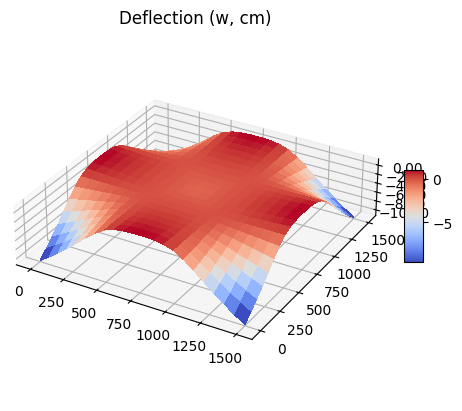

In [318]:
'Plotting Displacements'
xx = NodeCoord[:,0]
yy = NodeCoord[:,1]
Plot_PlateNodes(xx, yy, EX, EY, LX, LY, displacements, 'Deflection (w, cm)')

**Step 11: Calculating average bending moments $M_x$, $M_y$ and torsion $M_{xy}$ at the center of the plate.**

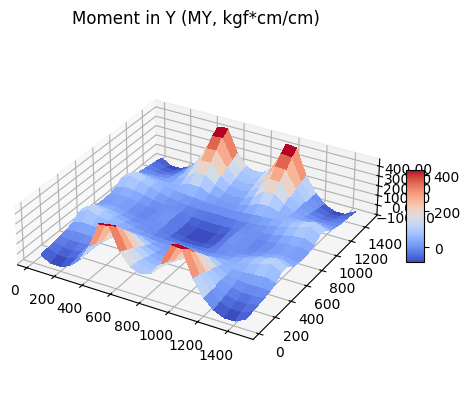

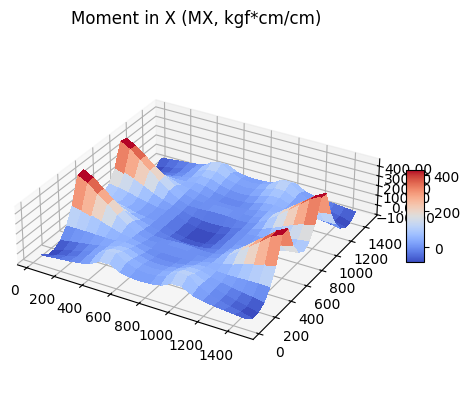

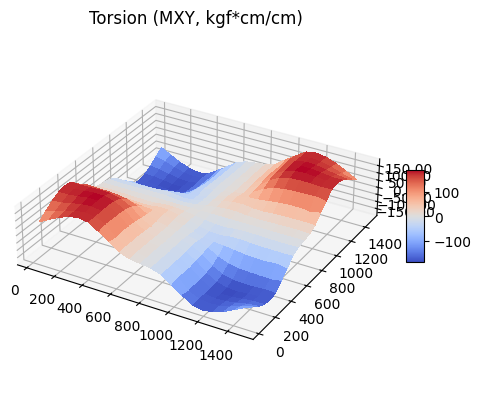

In [319]:
'Create the curvature matrix'
Curv = np.zeros((Elements, lenGpx, lenGpy, 3, 1), dtype=np.float64)
'Create Moment Matrix M'
M = np.zeros((Elements, lenGpx, lenGpy, 3, 1), dtype=np.float64)
'Create Moment in y Matrix My'
MY = np.zeros(Elements, dtype=np.float64)
'Create Moment in x Matrix Mx'
MX = np.zeros(Elements, dtype=np.float64)
'Create torsion Matrix Mxy'
MXY = np.zeros(Elements, dtype=np.float64)
for e in range(Elements):
    idx = ElementNodes[e].astype(int)
    idx = 3*idx
    idx_ = np.concatenate((idx, idx+1))
    idx_ = np.concatenate((idx_, idx+2))
    idx_.sort()
    for i in range(lenGpx):
        for j in range(lenGpy):
            kappa = Bij[e, i, j, :, :] @ displacements[idx_]
            Curv[e, i, j, :, :] = kappa
            if VoidCheck[e] == 1:
                M[e, i, j, :, :] = D_sol @ kappa
            else:
                M[e, i, j, :, :] = D_void @ kappa
    'Take the mean over the all Gauss Points as the value on the center of the plate element'
    MY[e] = .25*(M[e, 0, 0, 0, 0] + M[e, 0, 1, 0, 0] + M[e, 1, 0, 0, 0] + M[e, 1, 1, 0, 0])
    MX[e] = .25*(M[e, 0, 0, 1, 0] + M[e, 0, 1, 1, 0] + M[e, 1, 0, 1, 0] + M[e, 1, 1, 1, 0])
    MXY[e] = .25*(M[e, 0, 0, 2, 0] + M[e, 0, 1, 2, 0] + M[e, 1, 0, 2, 0] + M[e, 1, 1, 2, 0])
dx = LX/EX
dy = LY/EY
MXY_2d = np.reshape(MXY, (EX, EY))
Plot_PlateCenter(xx, yy, EX, EY, LX, LY, MY, 'Moment in Y (MY, kgf*cm/cm)')
Plot_PlateCenter(xx, yy, EX, EY, LX, LY, MX, 'Moment in X (MX, kgf*cm/cm)')
Plot_PlateCenter(xx, yy, EX, EY, LX, LY, MXY, 'Torsion (MXY, kgf*cm/cm)')

**Step 12: Calculating Shear Forces**

In [ ]:
'Shear in X'
MY_2d = np.reshape(MY, (EX, EY))
VX = np.gradient(MY_2d, dx, axis=0) + np.gradient(MXY_2d, dy, axis=1)
Plot_PlateCenter(xx, yy, EX, EY, LX, LY, VX, 'Shear in X (VX, kgf)')
'Shear in Y'
MX_2d = np.reshape(MX, (EX, EY))
VY = np.gradient(MX_2d, dy, axis=1) + np.gradient(MXY_2d, dx, axis=0)
Plot_PlateCenter(xx, yy, EX, EY, LX, LY, VY, 'Shear in Y (VY, kgf)')

..